<a href="https://colab.research.google.com/github/arielsharonferdinandus/Credit-Card-Clients-Risk-Prediction/blob/data-understanding-and-validation/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Customer Credit Card Default Risk from Historical Financial Data

**A Leakage-Aware, Imbalance-Aware, Reproducible Binary Classification Study**

---

**Dataset:** `default-of-credit-card-clients.csv` (UCI Machine Learning Repository — *Default of Credit Card Clients*, I-Cheng Yeh, 2016, DOI: 10.24432/C55S3E)

**Task type:** Binary classification

**Target:** `default payment next month` (0 = Non-default, 1 = Default)

---


## 1. Executive Project Summary (Preliminary)

- **Problem:** Predict whether a credit card client will default on their payment next month.
- **Dataset:** UCI *Default of Credit Card Clients* — 30,000 clients, 25 columns (23 numeric,
  2 categorical-coded-as-numeric: `SEX`, and jointly `EDUCATION`/`MARRIAGE`), Taiwan, 2005.
- **Target:** `default payment next month` — binary (0 = non-default, 1 = default).
- **Prediction timing:** The model must predict default risk *before* the due date of the target
  month, using only information available up to that point (demographics, credit limit, and the
  six most recent repayment-status/billing/payment records). No information from *after* the
  target month may be used — this is the central leakage constraint of the project.
- **Main modeling strategy:** Stratified train/validation/test split; scikit-learn `Pipeline` +
  `ColumnTransformer` for preprocessing fitted only on the training fold; a majority-class
  baseline, an interpretable Logistic Regression model, and a tree-based ensemble
  (Random Forest, optionally Gradient Boosting), compared on the validation set and evaluated
  once on the test set.
- **Primary metric:** F1-score for the positive class (Default = 1), because both missing a
  true default (false negative → credit loss) and flagging a good client (false positive →
  lost business) carry real cost, and F1 balances precision and recall on the minority class.
- **Key methodological constraints:**
  - `EDUCATION` contains undocumented codes (0, 5, 6) outside the documented 1–4 range.
  - `MARRIAGE` contains an undocumented code (0) outside the documented 1–3 range.
  - `PAY_0`…`PAY_6` contain sentinel values -2 and -1 that do **not** mean "very early
    payment" — they mean *no consumption / revolving balance* and *paid in full*, respectively,
    and must be interpreted semantically, not as ordinary integers.
  - All preprocessing parameters (scaler means/variances, one-hot categories) are fit
    **only** on the training split.
- **Class imbalance:** ~22.1% of clients defaulted (6,636 / 30,000); ~77.9% did not — an
  imbalance ratio of roughly 3.5 : 1, which makes raw accuracy a misleading metric.
- **Expected stakeholder use:** A credit risk team could use validated default-probability
  estimates to prioritize review, adjust credit limits, or trigger proactive outreach for
  high-risk accounts — while treating the model's output as *predictive association*, not
  *proof of causation*.


## 2. Project Overview

### Business / problem context
Credit card issuers extend revolving credit and carry the risk that a cardholder will fail to
make the required payment in a given month. Being able to anticipate this risk before the due
date lets a financial institution intervene early — e.g., through credit-limit adjustment,
targeted reminders, or proactive collections — rather than reacting only after a client has
already defaulted.

### Predictive question
> *"Using historical billing, repayment status, and demographic information, can we identify
> credit card clients who are likely to default on their next month's payment?"*

### Task type
Binary classification. `default payment next month` ∈ {0, 1}.

### Unit of analysis
One credit card account holder (one row per client).

### Prediction timing
The model is trained to predict default risk **before** the payment due date of the target
month, using only demographic attributes and the six most recent months of repayment status,
bill statements, and payment amounts available *up to that point*. No feature may encode
information that would only be known *after* the target month's due date has passed.

### Definition of a positive prediction
`1` = the model predicts the client **will default** on next month's payment.

`0` = the model predicts the client **will not default**.

### What the model is NOT intended to claim
The model estimates a **statistical association** between a client's profile/history and the
probability of default. It does **not** establish that any feature — e.g., a repayment delay,
education level, or credit limit — *causes* default. Feature importance describes what the
model found *predictive* in this dataset, not a causal mechanism. Three distinct claims must
stay separated throughout this project:

1. **Predictive usefulness** — does the feature help the model discriminate defaulters from
   non-defaulters?
2. **Operational usefulness** — can a decision-maker act on the model's output in a way that
   plausibly reduces losses or improves outcomes?
3. **Causal interpretation** — does the feature *cause* the outcome? (Not established by this
   study; would require a causal design, e.g. quasi-experimental variation or intervention data.)

### Stakeholder value
A credit risk evaluation team can use a validated, well-calibrated classifier to flag
high-risk accounts early, informing credit-limit decisions and risk-mitigation outreach —
subject to fair-lending and regulatory review, since `SEX`, `EDUCATION`, and `MARRIAGE` are
protected or quasi-protected attributes in many jurisdictions.


## 3. Dataset Description and Source

### Source

| Field | Value |
|---|---|
| Dataset title | Default of Credit Card Clients |
| Publisher / owner | UCI Machine Learning Repository |
| Creator | I-Cheng Yeh |
| Official URL | https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients |
| DOI | 10.24432/C55S3E |
| Citation | Yeh, I. C. (2016). *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3E |
| Access date | 2026-09-26 |
| Local filename used | `default-of-credit-card-clients.csv` (exported from the supplied `.xls` file; values are unchanged) |
| Dataset dimensions (expected) | 30,000 rows × 25 columns |
| Observation unit | One credit card account holder |
| Target column | `default payment next month` |

### Predictor groups
- **Demographics:** `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`
- **Credit line:** `LIMIT_BAL`
- **Repayment status (most recent 6 months):** `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6`
- **Bill statements (most recent 6 months):** `BILL_AMT1`…`BILL_AMT6`
- **Previous payments (most recent 6 months):** `PAY_AMT1`…`PAY_AMT6`
- **Identifier (non-predictive):** `ID`



### Data Dictionary

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# Reproducibility: fix the global random seed used throughout the notebook.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Table 2: Data dictionary and variable roles.
data_dictionary = pd.DataFrame([
    ("ID",         "int",  "Row identifier assigned by the data provider",                 "Identifier", "No",  "Non-predictive; would leak nothing but adds no signal and must never enter the feature matrix"),
    ("LIMIT_BAL",  "float","Amount of given credit (NT dollar), individual + family",       "Demographic/Credit", "Yes", ""),
    ("SEX",        "int",  "Gender (1 = male, 2 = female)",                                 "Demographic", "Yes", ""),
    ("EDUCATION",  "int",  "Education level (documented: 1=grad school,2=university,3=high school,4=others; undocumented: 0,5,6 observed)", "Demographic", "Yes", "Undocumented codes merged into 'Others' — see Data Quality Assessment"),
    ("MARRIAGE",   "int",  "Marital status (documented: 1=married,2=single,3=others; undocumented: 0 observed)", "Demographic", "Yes", "Undocumented code merged into 'Others' — see Data Quality Assessment"),
    ("AGE",        "int",  "Age in years",                                                  "Demographic", "Yes", ""),
    ("PAY_0",      "int",  "Repayment status, most recent month (Sept). -2=no consumption, -1=paid in full, 0=revolving credit used/paid minimum, 1..9=months delayed", "Repayment status", "Yes", ""),
    ("PAY_2",      "int",  "Repayment status, 1 month prior (Aug), same coding as PAY_0",    "Repayment status", "Yes", ""),
    ("PAY_3",      "int",  "Repayment status, 2 months prior (Jul)",                          "Repayment status", "Yes", ""),
    ("PAY_4",      "int",  "Repayment status, 3 months prior (Jun)",                          "Repayment status", "Yes", ""),
    ("PAY_5",      "int",  "Repayment status, 4 months prior (May)",                          "Repayment status", "Yes", ""),
    ("PAY_6",      "int",  "Repayment status, 5 months prior (Apr)",                          "Repayment status", "Yes", ""),
    ("BILL_AMT1",  "float","Bill statement amount, most recent month",                        "Bill statement", "Yes", ""),
    ("BILL_AMT2",  "float","Bill statement amount, 1 month prior",                             "Bill statement", "Yes", ""),
    ("BILL_AMT3",  "float","Bill statement amount, 2 months prior",                            "Bill statement", "Yes", ""),
    ("BILL_AMT4",  "float","Bill statement amount, 3 months prior",                            "Bill statement", "Yes", ""),
    ("BILL_AMT5",  "float","Bill statement amount, 4 months prior",                            "Bill statement", "Yes", ""),
    ("BILL_AMT6",  "float","Bill statement amount, 5 months prior",                            "Bill statement", "Yes", ""),
    ("PAY_AMT1",   "float","Amount paid, most recent month",                                   "Previous payment", "Yes", ""),
    ("PAY_AMT2",   "float","Amount paid, 1 month prior",                                        "Previous payment", "Yes", ""),
    ("PAY_AMT3",   "float","Amount paid, 2 months prior",                                       "Previous payment", "Yes", ""),
    ("PAY_AMT4",   "float","Amount paid, 3 months prior",                                       "Previous payment", "Yes", ""),
    ("PAY_AMT5",   "float","Amount paid, 4 months prior",                                       "Previous payment", "Yes", ""),
    ("PAY_AMT6",   "float","Amount paid, 5 months prior",                                       "Previous payment", "Yes", ""),
    ("default payment next month", "int (0/1)", "Target: did the client default on the following month's payment?", "Target", "Target (not a feature)", ""),
], columns=["column", "dtype", "conceptual_meaning", "role", "retained_for_modeling", "notes"])

data_dictionary


,column,dtype,conceptual_meaning,role,retained_for_modeling,notes
0,ID,int,Row identifier assigned by the data provider,Identifier,No,Non-predictive; would leak nothing but adds no...
1,LIMIT_BAL,float,"Amount of given credit (NT dollar), individual...",Demographic/Credit,Yes,
2,SEX,int,"Gender (1 = male, 2 = female)",Demographic,Yes,
3,EDUCATION,int,"Education level (documented: 1=grad school,2=u...",Demographic,Yes,Undocumented codes merged into 'Others' — see ...
4,MARRIAGE,int,"Marital status (documented: 1=married,2=single...",Demographic,Yes,Undocumented code merged into 'Others' — see D...
5,AGE,int,Age in years,Demographic,Yes,
6,PAY_0,int,"Repayment status, most recent month (Sept). -2...",Repayment status,Yes,
7,PAY_2,int,"Repayment status, 1 month prior (Aug), same co...",Repayment status,Yes,
8,PAY_3,int,"Repayment status, 2 months prior (Jul)",Repayment status,Yes,
9,PAY_4,int,"Repayment status, 3 months prior (Jun)",Repayment status,Yes,


## 4. Data Loading and Initial Verification

### Method
Load `default-of-credit-card-clients.csv` from a path **relative to the notebook's own
directory** (never a personal or machine-specific absolute path), then check shape, column
names, dtypes, and the presence/name of the target column against the documented expectations.

### Expected project directory structure
```
project/
├── Main.ipynb
├── default-of-credit-card-clients.csv
└── README.md
```

In [ ]:
# Portable, relative path resolution: works whether the notebook is run from
# Jupyter (cwd = notebook dir) or from `jupyter nbconvert --execute` elsewhere.
NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR / "default-of-credit-card-clients.csv"

assert DATA_PATH.exists(), (
    f"Expected dataset at {DATA_PATH}. "
    "Place 'default-of-credit-card-clients.csv' in the same folder as this notebook."
)

raw_data = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH.name}")
print(f"Shape: {raw_data.shape}")


Loaded: default-of-credit-card-clients.csv
Shape: (30000, 25)


In [ ]:
# Structural verification against the documented dataset facts.
EXPECTED_SHAPE = (30000, 25)
EXPECTED_TARGET = "default payment next month"

checks = {
    "shape is (30000, 25)": raw_data.shape == EXPECTED_SHAPE,
    "target column present": EXPECTED_TARGET in raw_data.columns,
    "ID column present": "ID" in raw_data.columns,
    "no fully-null columns": raw_data.isna().all().sum() == 0,
}
for description, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {description}")

assert all(checks.values()), "One or more structural checks failed — see printout above."


[PASS] shape is (30000, 25)
[PASS] target column present
[PASS] ID column present
[PASS] no fully-null columns


In [ ]:
print("Column names:")
print(list(raw_data.columns))
print()
print("Data types:")
print(raw_data.dtypes)


Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Data types:
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      in

In [ ]:
print("First rows:")
display(raw_data.head())
print("Last rows:")
display(raw_data.tail())


First rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


Last rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [ ]:
raw_data.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


### Result
The loaded file matches the documented shape (30,000 × 25), contains the expected target column
`default payment next month`, and all 25 expected columns are present with numeric dtypes
(`ID` and the two nominal-but-numeric-coded fields `SEX`/`EDUCATION`/`MARRIAGE` included).

## 5. Data Quality Assessment

### Objective

In this section, I examine the dataset by checking its number of rows and columns, data types, missing values, and duplicate records. I also verify whether categorical codes fall within the documented range and investigate each column for potential data leakage, particularly information that may only become available after the prediction point. The results of these checks are then used to determine the appropriate data preparation steps in §6.


### 5A–B. Shape and data types

In [ ]:
print(f"Rows: {raw_data.shape[0]:,}")
print(f"Columns: {raw_data.shape[1]}")
print()
numeric_cols = raw_data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric-typed columns ({len(numeric_cols)}): {numeric_cols}")
print()
print("Note: SEX, EDUCATION, MARRIAGE are stored as numeric codes but are conceptually "
      "nominal/categorical variables — they will be one-hot encoded in the modeling pipeline, "
      "not treated as ordinal numbers.")


Rows: 30,000
Columns: 25

Numeric-typed columns (25): ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Note: SEX, EDUCATION, MARRIAGE are stored as numeric codes but are conceptually nominal/categorical variables — they will be one-hot encoded in the modeling pipeline, not treated as ordinal numbers.


### 5C. Missing values
**Result:** We verify
dataset has 0 raw missing values detected.

In [ ]:
missing_table = pd.DataFrame({
    "missing_count": raw_data.isna().sum(),
    "missing_pct": (raw_data.isna().mean() * 100).round(3),
})
missing_table = missing_table[missing_table["missing_count"] > 0].sort_values("missing_count", ascending=False)
if missing_table.empty:
    print("No missing values detected in any column (0 / 0.000% across all 25 columns).")
else:
    display(missing_table)


No missing values detected in any column (0 / 0.000% across all 25 columns).


### 5D. Duplicate rows

In [ ]:
n_dupes = raw_data.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes} ({n_dupes / len(raw_data):.3%} of rows)")


Exact duplicate rows: 0 (0.000% of rows)


**Result:** No exact duplicate rows were found, so no de-duplication step is required.
(If duplicates existed, the decision would depend on whether `ID` values also repeated — a
repeated `ID` with identical feature values would indicate an ingestion artifact safe to drop;
distinct `ID`s with identical *features* could be legitimate coincidental matches and would need
closer inspection before removal.)

### 5E–F. Invalid / undocumented categories and sentinel values

The documented UCI coding is:
- `EDUCATION`: 1 = graduate school, 2 = university, 3 = high school, 4 = others (0, 5, 6 are
  **not** documented).
- `MARRIAGE`: 1 = married, 2 = single, 3 = others (0 is **not** documented).
- `PAY_0`…`PAY_6`: -1 = pay duly (paid in full/on time), 1–9 = months delayed. The value **-2**
  is a de-facto sentinel widely used in this dataset to mean *no consumption / no balance to
  repay that month*, and **0** commonly denotes *revolving credit used and the minimum due was
  paid*. None of -2, -1, 0 represent "delay" — treating them as ordinary ordinal delay counts
  would misstate a client's risk (e.g. -2 is not "2 months ahead of schedule").


In [ ]:
print("EDUCATION value counts:")
print(raw_data["EDUCATION"].value_counts().sort_index())
print()
print("MARRIAGE value counts:")
print(raw_data["MARRIAGE"].value_counts().sort_index())


EDUCATION value counts:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [ ]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
pay_value_counts = pd.DataFrame({c: raw_data[c].value_counts().sort_index() for c in pay_cols}).fillna(0).astype(int)
pay_value_counts


,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


In [ ]:
undocumented_education = raw_data["EDUCATION"].isin([0, 5, 6]).sum()
undocumented_marriage = raw_data["MARRIAGE"].isin([0]).sum()
print(f"EDUCATION undocumented codes (0, 5, 6): {undocumented_education} rows "
      f"({undocumented_education / len(raw_data):.3%})")
print(f"MARRIAGE undocumented code (0): {undocumented_marriage} rows "
      f"({undocumented_marriage / len(raw_data):.3%})")
print()
sentinel_no_consumption = (raw_data[pay_cols] == -2).sum()
sentinel_paid_in_full = (raw_data[pay_cols] == -1).sum()
print("PAY_X = -2 (no consumption) counts per column:")
print(sentinel_no_consumption)
print()
print("PAY_X = -1 (paid in full) counts per column:")
print(sentinel_paid_in_full)


EDUCATION undocumented codes (0, 5, 6): 345 rows (1.150%)
MARRIAGE undocumented code (0): 54 rows (0.180%)

PAY_X = -2 (no consumption) counts per column:
PAY_0    2759
PAY_2    3782
PAY_3    4085
PAY_4    4348
PAY_5    4546
PAY_6    4895
dtype: int64

PAY_X = -1 (paid in full) counts per column:
PAY_0    5686
PAY_2    6050
PAY_3    5938
PAY_4    5687
PAY_5    5539
PAY_6    5740
dtype: int64


**Result:**
- `EDUCATION` codes {0, 5, 6} will be merged into category `4` ("Others") — they are rare
  (≈1.6% combined), undocumented, and semantically closest to an "unspecified/other" bucket
  rather than a distinct education level.
- `MARRIAGE` code {0} will be merged into category `3` ("Others") for the same reason
  (≈0.18% of rows).
- `PAY_X` sentinel values -2 and -1 will **not** be silently treated as raw ordinal integers;
  §6.7 defines an explicit, documented encoding so both tree models and linear models see a
  sensible representation of "no delay" vs. "positive months of delay".


### Negative `BILL_AMT` values and `PAY_AMT` sign check

In [ ]:
neg_bill = (raw_data[[f"BILL_AMT{i}" for i in range(1, 7)]] < 0).sum()
print("Negative BILL_AMT values per column (can represent a credit balance / overpayment):")
print(neg_bill)
print()
neg_pay_amt = (raw_data[[f"PAY_AMT{i}" for i in range(1, 7)]] < 0).sum()
print("Negative PAY_AMT values per column (should be 0 — payments cannot be negative):")
print(neg_pay_amt)


Negative BILL_AMT values per column (can represent a credit balance / overpayment):
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64

Negative PAY_AMT values per column (should be 0 — payments cannot be negative):
PAY_AMT1    0
PAY_AMT2    0
PAY_AMT3    0
PAY_AMT4    0
PAY_AMT5    0
PAY_AMT6    0
dtype: int64


**Interpretation:** Negative `BILL_AMT` values are financially plausible — a negative
statement balance represents an overpayment or credit sitting on the account rather than an
error, so these rows are **retained** as valid observations (see the outlier discussion in §6.6
for the fuller treatment). `PAY_AMT` columns show no negative values, consistent with the
non-negativity constraint on actual payments made.

### 5G. Target distribution and Accuracy

In [ ]:
target_col = "default payment next month"
target_counts = raw_data[target_col].value_counts().sort_index()
target_pct = raw_data[target_col].value_counts(normalize=True).sort_index() * 100

# Table 1: Dataset dimensions and target distribution.
table1 = pd.DataFrame({
    "class": ["0 (Non-default)", "1 (Default)"],
    "count": target_counts.values,
    "percentage": target_pct.round(2).values,
})
print(f"Dataset dimensions: {raw_data.shape[0]:,} rows x {raw_data.shape[1]} columns")
display(table1)
imbalance_ratio = target_counts[0] / target_counts[1]
print(f"Imbalance ratio (non-default : default) = {imbalance_ratio:.2f} : 1")


Dataset dimensions: 30,000 rows x 25 columns


,class,count,percentage
0,0 (Non-default),23364,77.88
1,1 (Default),6636,22.12


Imbalance ratio (non-default : default) = 3.52 : 1


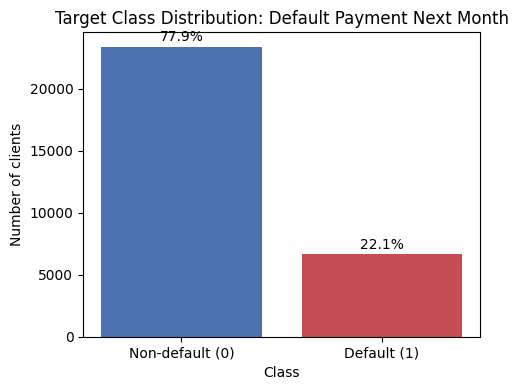

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Non-default (0)", "Default (1)"], target_counts.values, color=["#4C72B0", "#C44E52"])
ax.set_title("Target Class Distribution: Default Payment Next Month")
ax.set_ylabel("Number of clients")
ax.set_xlabel("Class")
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


**Accuracy alone is misleading:** a trivial classifier that predicts "no default"
for *every* client would already be correct ~77.9% of the time, purely by exploiting the class
imbalance, while catching **zero** actual defaulters — the exact clients a credit risk team
most needs to identify. A high accuracy score can therefore coexist with a model that is
operationally useless. This is why we designates **F1-score on the positive (Default) class**
— not accuracy — as the primary evaluation metric, and why we requires a majority-class
baseline to make this gap explicit and measurable rather than asserted.

### 5H. Leakage audit

### Method
Explicitly enumerate every column and ask: *could this value only be known after the target
month's due date has passed?* This is a design-time audit (no code needs to run to answer it,
though the checks below confirm the structural facts the argument relies on).

### Findings
- **Target column** (`default payment next month`) is definitionally the outcome — obviously
  excluded from the feature set, verified by column-name checks and enforced
  `X`/`y` split.
- **`ID`** carries no predictive information and is not a legitimate feature; retaining it risks
  a model spuriously keying on row order or ID-encoded artifacts. It **must be dropped** from
  the modeling feature set.
- **`PAY_0`…`PAY_6`, `BILL_AMT1`…`BILL_AMT6`, `PAY_AMT1`…`PAY_AMT6`** are all historical —
  they describe the **six months up to and including the most recent billing cycle**, all of
  which precede the target month's due date. None of these describe the target month's own
  outcome, so none of them are leakage by construction *in this dataset as provided*. This
  dataset does not contain any column that describes billing/payment behavior *after* the
  target month, so no additional post-period columns need to be excluded beyond `ID`.
- **No feature in this dataset is computed using statistics from the full dataset** at this
  point — `raw_data` is the untouched load. Any leakage risk from here onward would come from
  *procedure* (e.g., fitting a scaler before splitting), not from the raw columns themselves.
  enforce split-before-fit as a hard rule to prevent this failure mode.

### Decision / implication
The **only** structural exclusion required before modeling is `ID`. All other 23 non-target
columns are legitimate, pre-target-month predictors. The leakage risk in this project is
therefore primarily a *procedural* risk (fitting preprocessing on data outside the training
fold) rather than a *feature-selection* risk — which is why all reiterate the
train-only-fit rule from different angles.


### Data Quality Summary Table

In [ ]:
# Table 3: Quality audit (undocumented categories & missing values).
table3 = pd.DataFrame([
    ("Missing values (any column)", int(raw_data.isna().sum().sum()), "0.000%", "None — no imputation required"),
    ("Exact duplicate rows", int(n_dupes), f"{n_dupes/len(raw_data):.3%}", "None — no de-duplication required"),
    ("EDUCATION undocumented codes (0,5,6)", int(undocumented_education), f"{undocumented_education/len(raw_data):.3%}", "Merge into category 4 ('Others')"),
    ("MARRIAGE undocumented code (0)", int(undocumented_marriage), f"{undocumented_marriage/len(raw_data):.3%}", "Merge into category 3 ('Others')"),
    ("BILL_AMT negative values (any month)", int((raw_data[[f'BILL_AMT{i}' for i in range(1,7)]] < 0).any(axis=1).sum()), None, "Retain — valid overpayment/credit balance"),
    ("Non-predictive ID column", 1, None, "Drop from feature matrix"),
], columns=["issue", "affected_rows_or_columns", "pct_of_rows", "decision"])
table3


,issue,affected_rows_or_columns,pct_of_rows,decision
0,Missing values (any column),0,0.000%,None — no imputation required
1,Exact duplicate rows,0,0.000%,None — no de-duplication required
2,"EDUCATION undocumented codes (0,5,6)",345,1.150%,Merge into category 4 ('Others')
3,MARRIAGE undocumented code (0),54,0.180%,Merge into category 3 ('Others')
4,BILL_AMT negative values (any month),1930,NaN,Retain — valid overpayment/credit balance
5,Non-predictive ID column,1,NaN,Drop from feature matrix


### Section 5 Result & Decision Summary
- Structural integrity confirmed: correct shape, no missing values, no exact duplicates.
- Two demographic columns contain undocumented category codes that will be consolidated into
  an "Others" bucket during preparation.
- `PAY_X` sentinel values (-2, -1) are semantically distinct from ordinary delay counts and will
  be handled explicitly, not left as raw integers fed into a linear model unexamined.
- Negative `BILL_AMT` values are valid (overpayment/credit) and are retained.
- The only column requiring exclusion from the feature matrix on leakage/non-predictive grounds
  is `ID`.
- These decisions collectively define the scope of Data Preparation, which is the next
  section of this notebook.


---
## Next Steps (Not Yet Implemented in This Version)

This notebook currently implements project framing,
dataset documentation, data loading/verification, and the full data-quality/leakage audit.

The remaining sections — **Data Preparation, EDA, Feature Engineering,
Train/Val/Test Split, Preprocessing Pipeline, Baseline + Logistic Regression +
Ensemble models, Hyperparameter Tuning, Threshold Analysis, Model
Comparison & Selection, Final Test Evaluation, Diagnostics, Feature
Importance, and the Final Conclusion** — build directly on the decisions documented
above and will be added next.
